# Домашная работа 3. Визуальный анализ.

1. Скачайте этот ноутбук к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём репозитории.

#### Полезная литература

- [Галерея графиков Matplotlib](https://matplotlib.org/gallery/index.html)
- [Галерея графиков Seaborn](http://seaborn.pydata.org/examples/index.html)
- [Открытый курс машинного обучения. Тема 2: Визуализация данных c Python](https://habr.com/company/ods/blog/323210/)

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Визуальный анализ данных

В этом задании вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams. 

In [118]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


## Задания
#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


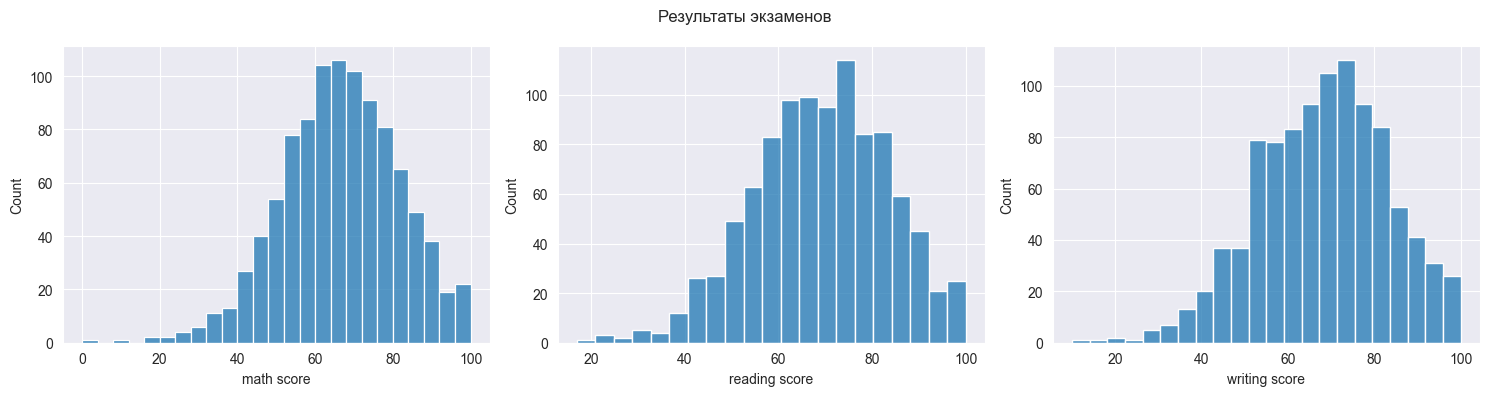

In [119]:
fig = plt.figure(figsize=(15, 4))
fig.suptitle("Результаты экзаменов")

ax_1 = fig.add_subplot(1, 3, 1)
ax_2 = fig.add_subplot(1, 3, 2)
ax_3 = fig.add_subplot(1, 3, 3)

sns.histplot(df["math score"], ax=ax_1)
sns.histplot(df["reading score"], ax=ax_2)
sns.histplot(df["writing score"], ax=ax_3)

plt.tight_layout()
plt.show()

In [120]:
print("Медиана math score:", df["math score"].mean())
print("Медиана reading score:", df["reading score"].mean())
print("Медиана writing score:", df["writing score"].mean())

Медиана math score: 66.089
Медиана reading score: 69.169
Медиана writing score: 68.054


#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню? 

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


In [121]:
print("Уровни образования в столбце 'parental level of education':", df["parental level of education"].unique(), sep='\n')
print()
print("Сколько строк в датафрейме соответствует каждому уровню:", df["parental level of education"].value_counts(), sep="\n")

Уровни образования в столбце 'parental level of education':
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

Сколько строк в датафрейме соответствует каждому уровню:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


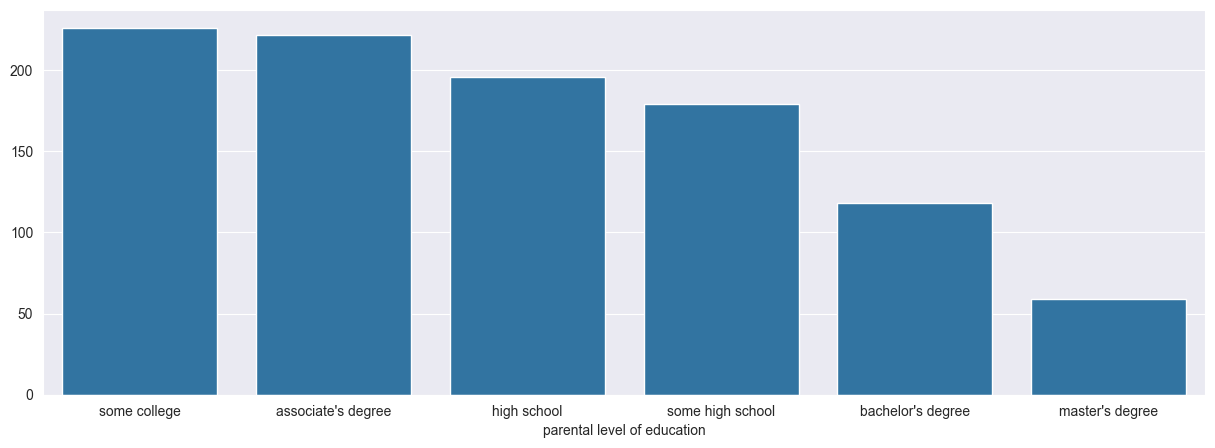

In [122]:
p_edu = df["parental level of education"].value_counts()


plt.figure(figsize=(15, 5))
sns.barplot(x=p_edu.index, y=p_edu.values)

plt.show()

<Axes: xlabel='parental level of education', ylabel='math score'>

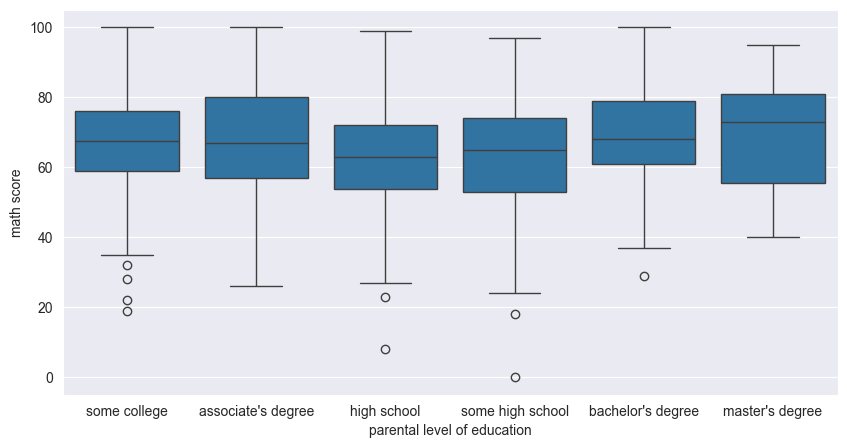

In [123]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="parental level of education", y="math score", data=df, order=p_edu.index)

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [124]:
df[(df["gender"] == "female") & (df["math score"] > 90) & (df["reading score"] > 90) & (df["writing score"] > 90)].shape[0]

17

#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение
 

In [125]:
math = df.groupby("gender")["math score"].agg(["min", "max", "median"])
math

,min,max,median
gender,,,
female,0,100,65.0
male,27,100,69.0


In [126]:
reading = df.groupby("gender")["reading score"].agg(["min", "max", "median"])
reading

,min,max,median
gender,,,
female,17,100,73.0
male,23,100,66.0


In [127]:
writing = df.groupby("gender")["writing score"].agg(["min", "max", "median"])
writing

,min,max,median
gender,,,
female,10,100,74.0
male,15,100,64.0


#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола 
###### (подсказка: используете agg())

In [128]:
df.groupby(
    ['gender', 'lunch', 'test preparation course']
)[['math score', 'reading score', 'writing score']].agg('mean')

math score  reading score  \
gender lunch        test preparation course                              
female free/reduced completed                 60.785714      73.428571   
                    none                      52.890756      63.831933   
       standard     completed                 71.131579      79.798246   
                    none                      66.530233      73.386047   
male   free/reduced completed                 65.639344      65.786885   
                    none                      60.609524      59.076190   
       standard     completed                 75.955752      72.601770   
                    none                      69.832512      64.719212   

                                             writing score  
gender lunch        test preparation course                 
female free/reduced completed                    74.371429  
                    none                         61.781513  
       standard     completed                    81.508772  
                    none                         72.967442  
male   free/reduced completed                    65.737705  
                    none                         55.285714  
       standard     completed                    71.982301  
                    none                         61.906404

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы 

<Axes: xlabel='race/ethnicity', ylabel='count'>

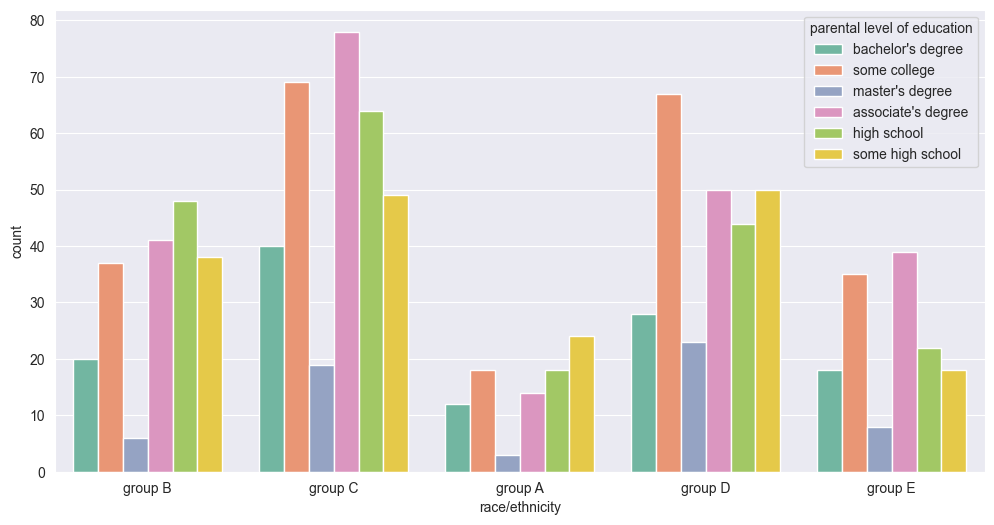

In [129]:
plt.figure(figsize=(12,6))
sns.countplot(
    x='race/ethnicity',
    hue='parental level of education',
    data=df,
    palette='Set2'
)

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

<Axes: xlabel='parental level of education', ylabel='count'>

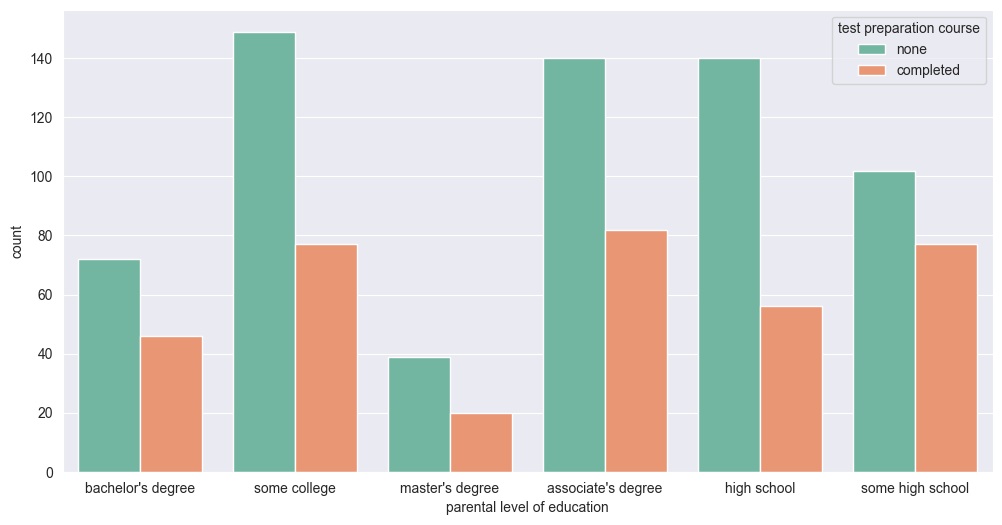

In [130]:
plt.figure(figsize=(12,6))
sns.countplot(
    x='parental level of education',
    hue='test preparation course',
    data=df,
    palette='Set2'
)

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

([<matplotlib.patches.Wedge at 0x1b3cbd7df10>,
 [Text(-1.0864571786893613, 0.17207788607009664, 'pass'),
  Text(1.0864571937328844, -0.17207779108898907, 'fail')])

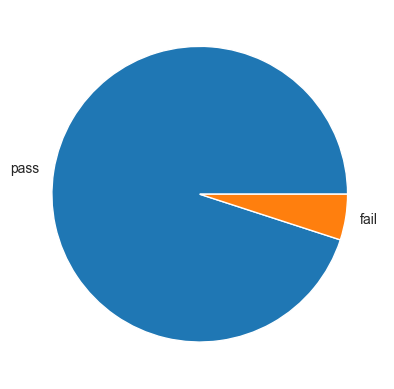

In [131]:
df["is passed math"] = df["math score"] > 40

labels = ["pass", "fail"]
x = [df[df["is passed math"] == True].shape[0], df[df["is passed math"] == False].shape[0]]

plt.pie(x=x, labels=labels)

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

In [132]:
means = (df["math score"] + df["reading score"] + df["writing score"]) / 3

conditions = [
    (~df["is passed math"]) | (means <= 40),
    (means > 40) & (means <= 60),
    (means > 60) & (means <= 70),
    (means > 70) & (means <= 80),
    (means > 80) & (means <= 90),
    (means > 90) & (means <= 100)
]

grades = [
    "grade E",
    "grade D",
    "grade C",
    "grade B",
    "grade A",
    "grade O"
]

import numpy as np
df["score"] = np.select(conditions, grades, default="grade E")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,is passed math,score
0,female,group B,bachelor's degree,standard,none,72,72,74,True,grade B
1,female,group C,some college,standard,completed,69,90,88,True,grade A
2,female,group B,master's degree,standard,none,90,95,93,True,grade O
3,male,group A,associate's degree,free/reduced,none,47,57,44,True,grade D
4,male,group C,some college,standard,none,76,78,75,True,grade B
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,True,grade O
996,male,group C,high school,free/reduced,none,62,55,55,True,grade D
997,female,group C,high school,free/reduced,completed,59,71,65,True,grade C
998,female,group D,some college,standard,completed,68,78,77,True,grade B


<Axes: ylabel='count'>

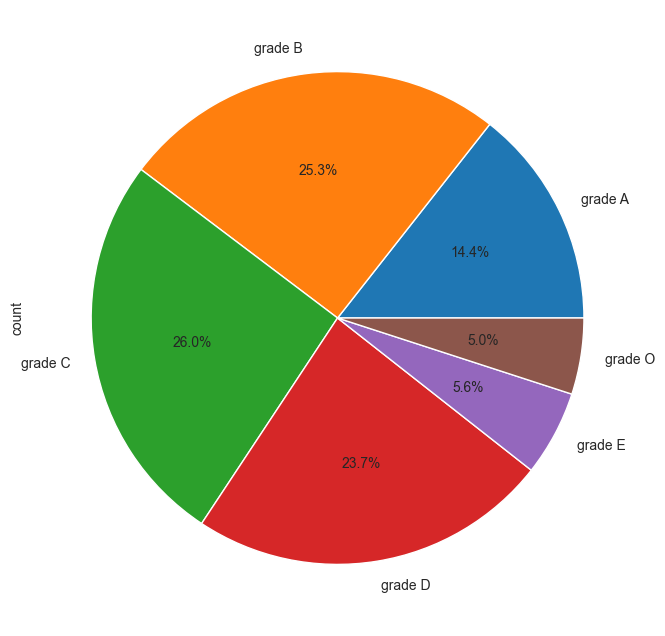

In [133]:
grade_counts = df["score"].value_counts().sort_index()
plt.figure(figsize=(8,8))
grade_counts.plot.pie(autopct="%1.1f%%")

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

<Axes: xlabel='score', ylabel='count'>

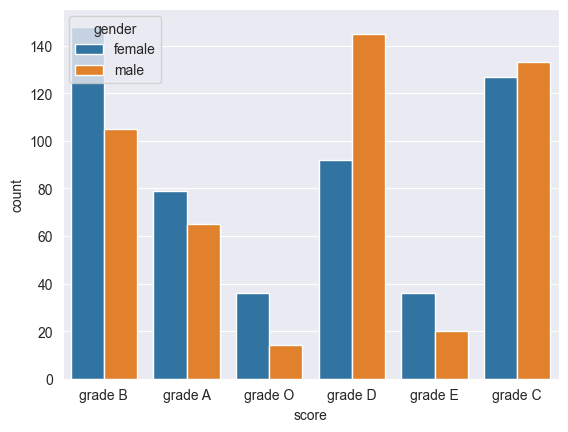

In [134]:
sns.countplot(x="score", hue="gender", data=df)